In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm

def _find_project_root(marker="requirements.txt"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate project root (missing {marker})")

DATA_DIR = _find_project_root() / "O" / "U" / "Data"

# 1. LOAD DATA
# TRAIN on all of 2025, TEST on all of 2026 (true out-of-sample)
train = pd.read_csv(DATA_DIR / 'games_2025_features.csv', parse_dates=['Date'])
train = train.sort_values('Date').reset_index(drop=True)

test = pd.read_csv(DATA_DIR / 'games_2026_features.csv', parse_dates=['Date'])
test = test.sort_values('Date').reset_index(drop=True)

# 2026 odds for the backtest
odds_raw = pd.read_csv(DATA_DIR / 'mlb_totals_2026_raw.csv')

print(f"Train (2025): {len(train)} games")
print(f"Test  (2026): {len(test)} games")

Train (2025): 1934 games
Test  (2026): 878 games


In [2]:
# 3. FIT BOTH RUN MODELS on TRAIN only (Poisson GLM, log link)

home_features = ['home_off_roll20', 'away_def_roll10']
away_features = ['away_off_roll20', 'home_def_roll10']
 
model_home = sm.GLM(train['home_runs'],
                    sm.add_constant(train[home_features]),
                    family=sm.families.Poisson()).fit()
 
model_away = sm.GLM(train['away_runs'],
                    sm.add_constant(train[away_features]),
                    family=sm.families.Poisson()).fit()
 
# Generate lambdas (expected runs) for every test game
test['lambda_home'] = model_home.predict(sm.add_constant(test[home_features]))
test['lambda_away'] = model_away.predict(sm.add_constant(test[away_features]))
 
test['actual_total'] = test['home_runs'] + test['away_runs']
 
print(f"Mean lambda_home: {test['lambda_home'].mean():.2f}")
print(f"Mean lambda_away: {test['lambda_away'].mean():.2f}")
print(test[['home_team','away_team','lambda_home','lambda_away','actual_total']].head())

Mean lambda_home: 4.48
Mean lambda_away: 4.46
  home_team away_team  lambda_home  lambda_away  actual_total
0       CLE       BAL     4.247384     4.408787          12.0
1       NYY       KCR     4.633477     4.640029           7.0
2       LAA       SDP     4.355285     4.543993           3.0
3       CLE       HOU     4.891001     4.618340          11.0
4       COL       LAD     4.243981     4.727068          15.0


In [3]:
home_features = ['home_off_roll20', 'away_def_roll10']
away_features = ['away_off_roll20', 'home_def_roll10']
 
# --- Fit NegBin (MLE) on TRAIN — this estimates alpha jointly with coefs ---
nb_home = sm.NegativeBinomial(
    train['home_runs'],
    sm.add_constant(train[home_features])
).fit(disp=0)
 
nb_away = sm.NegativeBinomial(
    train['away_runs'],
    sm.add_constant(train[away_features])
).fit(disp=0)
 
# statsmodels stores the estimated dispersion as the last param, named 'alpha'
alpha_home = nb_home.params['alpha']
alpha_away = nb_away.params['alpha']
 
print(f"Fitted alpha (home runs): {alpha_home:.4f}")
print(f"Fitted alpha (away runs): {alpha_away:.4f}")
print(f"\n(We had been guessing alpha = 0.15)")
 
# Sanity: alpha should be > 0 (confirms overdispersion is real, Poisson too thin)
print(f"\nBoth positive -> overdispersion confirmed, NegBin justified: "
      f"{alpha_home > 0 and alpha_away > 0}")

Fitted alpha (home runs): 0.2888
Fitted alpha (away runs): 0.3765

(We had been guessing alpha = 0.15)

Both positive -> overdispersion confirmed, NegBin justified: True


In [4]:
# 4. MONTE CARLO SIMULATOR (NegBin — our chosen model)

def _negbin_draw(mean, alpha, n_sims):
    n = 1.0 / alpha
    p = n / (n + mean)
    return np.random.negative_binomial(n, p, n_sims)
 
def simulate_game(lambda_home, lambda_away, line,
                  alpha_home, alpha_away, n_sims=10000):
    """NegBin sim with SEPARATE fitted dispersion for home and away."""
    home = _negbin_draw(lambda_home, alpha_home, n_sims)
    away = _negbin_draw(lambda_away, alpha_away, n_sims)
    totals = home + away
    return np.mean(totals > line)

In [5]:
# 5. BUILD CONSENSUS MARKET LINES

consensus = odds_raw.groupby('event_id').agg(
    home_team=('home_team', 'first'),
    away_team=('away_team', 'first'),
    commence_time=('commence_time', 'first'),
    market_total=('total_line', 'mean'),   # consensus across books
    line_std=('total_line', 'std'),        # book disagreement (bonus signal)
    n_books=('total_line', 'size'),
).reset_index()
 
# Map full team names -> model abbreviations
name_to_abbr = {
    'Arizona Diamondbacks': 'ARI', 'Atlanta Braves': 'ATL',
    'Baltimore Orioles': 'BAL', 'Boston Red Sox': 'BOS',
    'Chicago Cubs': 'CHC', 'Chicago White Sox': 'CHW',
    'Cincinnati Reds': 'CIN', 'Cleveland Guardians': 'CLE',
    'Colorado Rockies': 'COL', 'Detroit Tigers': 'DET',
    'Miami Marlins': 'MIA', 'Houston Astros': 'HOU',
    'Kansas City Royals': 'KCR', 'Los Angeles Angels': 'LAA',
    'Los Angeles Dodgers': 'LAD', 'Milwaukee Brewers': 'MIL',
    'Minnesota Twins': 'MIN', 'New York Mets': 'NYM',
    'New York Yankees': 'NYY', 'Athletics': 'ATH', 'Oakland Athletics': 'ATH',
    'Philadelphia Phillies': 'PHI', 'Pittsburgh Pirates': 'PIT',
    'San Diego Padres': 'SDP', 'San Francisco Giants': 'SFG',
    'Seattle Mariners': 'SEA', 'St. Louis Cardinals': 'STL',
    'Tampa Bay Rays': 'TBR', 'Texas Rangers': 'TEX',
    'Toronto Blue Jays': 'TOR', 'Washington Nationals': 'WSN',
}
consensus['home_abbr'] = consensus['home_team'].map(name_to_abbr)
consensus['away_abbr'] = consensus['away_team'].map(name_to_abbr)
 
# Drop unmapped rows (All-Star game, exhibitions)
consensus = consensus.dropna(subset=['home_abbr', 'away_abbr']).reset_index(drop=True)
 
# Timezone-correct date: commence_time is UTC -> convert to US Eastern before extracting date
consensus['game_date'] = (
    pd.to_datetime(consensus['commence_time'])
    .dt.tz_convert('America/New_York').dt.date
)
 
print(f"Consensus games: {len(consensus)} | unique events: {consensus['event_id'].nunique()}")

Consensus games: 1301 | unique events: 1301


In [6]:
# 6. JOIN market lines onto test games

test['game_date'] = pd.to_datetime(test['Date']).dt.date
odds_slim = consensus[['game_date', 'home_abbr', 'away_abbr', 'market_total', 'line_std', 'n_books']]
 
test_odds = test.merge(
    odds_slim,
    left_on=['game_date', 'home_team', 'away_team'],
    right_on=['game_date', 'home_abbr', 'away_abbr'],
    how='inner',
)
 
# Drop doubleheader / residual duplicates (keep first — negligible loss for v1)
test_odds = test_odds.drop_duplicates(
    subset=['game_date', 'home_team', 'away_team'], keep='first'
).reset_index(drop=True)
 
print(f"Backtest games (model + market): {len(test_odds)}")

Backtest games (model + market): 866


In [7]:
# 7. SIMULATE P(over) AT EACH GAME'S REAL MARKET LINE

test_odds['p_over_model'] = test_odds.apply(
    lambda r: simulate_game(r['lambda_home'], r['lambda_away'],
                            line=r['market_total'],
                            alpha_home=alpha_home, alpha_away=alpha_away),
    axis=1
)
 
# Actual outcome at the real line
test_odds['actual_over'] = (test_odds['actual_total'] > test_odds['market_total']).astype(int)
 
# Edge = how far our probability diverges from a coin flip
test_odds['edge'] = test_odds['p_over_model'] - 0.5
 
print(test_odds[['home_team','away_team','market_total',
                 'p_over_model','actual_total','actual_over']].head(10))

  home_team away_team  market_total  p_over_model  actual_total  actual_over
0       CLE       BAL      6.545455        0.6393          12.0            1
1       NYY       KCR      7.954545        0.5912           7.0            0
2       LAA       SDP      8.500000        0.4813           3.0            0
3       CLE       HOU      7.454545        0.6121          11.0            1
4       COL       LAD     11.500000        0.2618          15.0            1
5       CHC       PHI      8.545455        0.4908          11.0            1
6       BOS       NYY      8.500000        0.4973           4.0            0
7       CLE       HOU      8.500000        0.5356          13.0            1
8       SEA       ATH      7.500000        0.5597           7.0            0
9       COL       SDP     10.944444        0.3523           1.0            0


In [8]:
# 8. CALIBRATION CHECK — do our probabilities match reality?

test_odds['prob_bucket'] = pd.cut(test_odds['p_over_model'],
                                  bins=[0, 0.45, 0.50, 0.55, 0.60, 0.65, 1.0])
 
calib = test_odds.groupby('prob_bucket', observed=True).agg(
    n_games=('actual_over', 'size'),
    predicted_avg=('p_over_model', 'mean'),
    actual_over_rate=('actual_over', 'mean'),
)
print(calib)
 
print(f"\nModel avg P(over): {test_odds['p_over_model'].mean():.3f}")
print(f"Actual over rate:  {test_odds['actual_over'].mean():.3f}")

             n_games  predicted_avg  actual_over_rate
prob_bucket                                          
(0.0, 0.45]      334       0.384568          0.523952
(0.45, 0.5]      188       0.474779          0.398936
(0.5, 0.55]      182       0.521742          0.439560
(0.55, 0.6]      123       0.571993          0.536585
(0.6, 0.65]       32       0.616747          0.500000
(0.65, 1.0]        7       0.660657          0.285714

Model avg P(over): 0.470
Actual over rate:  0.478


 ev_thresh strategy  n_bets  win_rate  final_bank  roi_pct  yield_pct
         2    fixed     606      50.0      449.09    -55.1      -4.55
         2    kelly     606      50.0      111.57    -88.8     -10.11
         3    fixed     568      49.5      369.09    -63.1      -5.55
         3    kelly     568      49.5      108.52    -89.1     -10.44
         4    fixed     533      49.0      305.45    -69.5      -6.52
         4    kelly     533      49.0      105.16    -89.5     -10.83
         5    fixed     496      49.0      358.18    -64.2      -6.47
         5    kelly     496      49.0      108.75    -89.1     -10.61
         6    fixed     455      48.8      376.36    -62.4      -6.85
         6    kelly     455      48.8      111.22    -88.9     -10.71
         7    fixed     416      47.8      278.18    -72.2      -8.68
         7    kelly     416      47.8      102.09    -89.8     -11.14
         8    fixed     382      46.3      118.18    -88.2     -11.54
         8    kelly 

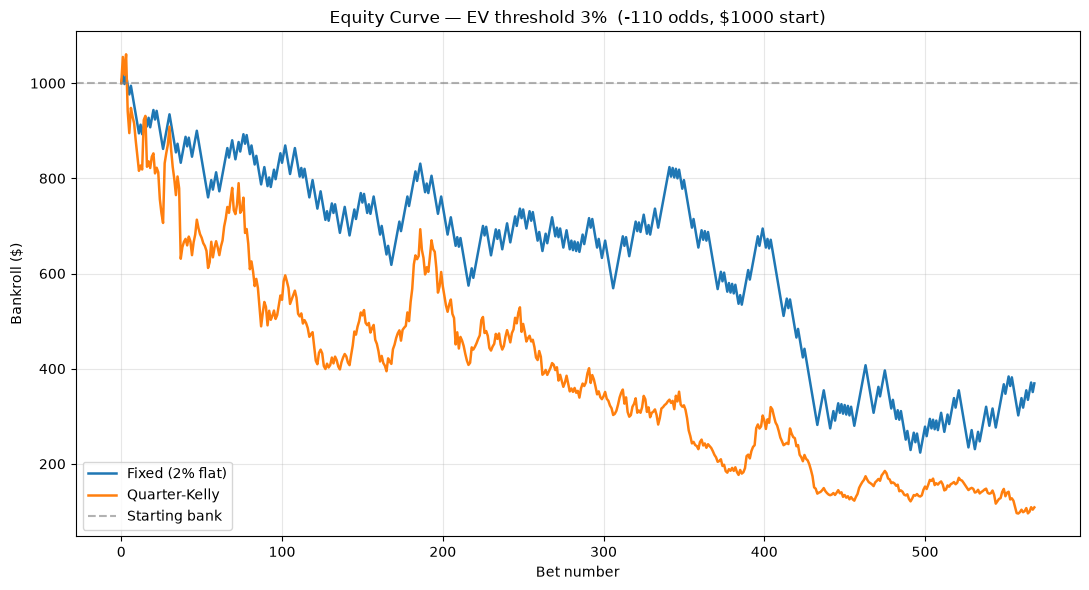

In [9]:
# %%
# ============================================================
# 9. P&L BACKTEST — fixed staking vs Kelly, across EV thresholds
#    -110 odds, $1000 bank. Bet OVER or UNDER based on model edge.
#    Also plots equity curves.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WIN_PROFIT = 100/110          # profit per $1 staked on a win at -110
BREAKEVEN  = 110/210          # ~0.5238 implied prob to break even

def run_backtest(df, ev_threshold_pct, strategy='fixed',
                 bank0=1000.0, fixed_frac=.02, kelly_frac=.25):
    """
    Returns summary dict + the equity curve (list of bank values after each bet).
    Bets are placed in chronological order (df should be date-sorted).
    """
    bank = bank0
    n_bets = n_wins = 0
    total_staked = 0.0
    equity = [bank0]                     # equity curve, starts at bank0

    for _, row in df.iterrows():
        p_over = row['p_over_model']
        p_under = 1 - p_over
        p_win, bet_over = (p_over, True) if p_over > p_under else (p_under, False)

        ev_pct = (p_win * WIN_PROFIT - (1 - p_win)) * 100
        if ev_pct < ev_threshold_pct:
            continue

        if strategy == 'fixed':
            stake = bank0 * fixed_frac
        else:  # fractional Kelly on current bank
            b = WIN_PROFIT
            f_star = max((b * p_win - (1 - p_win)) / b, 0)
            stake = bank * f_star * kelly_frac
        stake = min(stake, bank)
        if stake <= 0:
            continue

        actual_over = row['actual_over'] == 1
        won = (actual_over and bet_over) or ((not actual_over) and (not bet_over))

        total_staked += stake
        n_bets += 1
        bank += stake * WIN_PROFIT if won else -stake
        if won:
            n_wins += 1
        equity.append(bank)             # record after each resolved bet

    roi = (bank - bank0) / bank0 * 100
    win_rate = (n_wins / n_bets * 100) if n_bets else 0
    yield_pct = ((bank - bank0) / total_staked * 100) if total_staked else 0
    summary = {
        'ev_thresh': ev_threshold_pct, 'strategy': strategy,
        'n_bets': n_bets, 'win_rate': round(win_rate, 1),
        'final_bank': round(bank, 2), 'roi_pct': round(roi, 1),
        'yield_pct': round(yield_pct, 2),
    }
    return summary, equity

# Ensure chronological order so the equity curve is a real time path
test_odds = test_odds.sort_values('game_date').reset_index(drop=True)

# --- summary table across EV thresholds ---
results = []
for thresh in range(2, 11):
    for strat in ('fixed', 'kelly'):
        summ, _ = run_backtest(test_odds, thresh, strategy=strat)
        results.append(summ)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# %%
# ============================================================
# 10. EQUITY CURVES — fixed vs Kelly at a chosen EV threshold
# ============================================================
CHOSEN_EV = 3    # pick a threshold to visualize the bankroll path

_, eq_fixed = run_backtest(test_odds, CHOSEN_EV, strategy='fixed')
_, eq_kelly = run_backtest(test_odds, CHOSEN_EV, strategy='kelly')

plt.figure(figsize=(11, 6))
plt.plot(eq_fixed, label='Fixed (2% flat)', linewidth=1.8)
plt.plot(eq_kelly, label='Quarter-Kelly', linewidth=1.8)
plt.axhline(1000, color='gray', linestyle='--', alpha=0.6, label='Starting bank')
plt.title(f'Equity Curve — EV threshold {CHOSEN_EV}%  (-110 odds, $1000 start)')
plt.xlabel('Bet number')
plt.ylabel('Bankroll ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()